# **Capstone Project: Advanced Machine Learning**

---



# **Integrated Retail Analytics for Store Optimization and Demand Forecasting**

---



## **Project Type:**

Advanced Machine Learning | Time Series Forecasting | Clustering | Anomaly Detection | Retail
Intelligence

---



**Contribution: Individual**

---



**Project By: Rihansh Asawa**

---



---

---





# **PROJECT SUMMARY**

This project focuses on building an end-to-end Retail Intelligence and Demand Forecasting System using advanced machine learning and analytics techniques.

The project utilizes retail sales, store, and feature datasets to:



*   Detect anomalies in sales patterns

*   Forecast weekly demand across stores and departments

*   Analyze seasonal and holiday impacts

*   Segment stores based on operational patterns

*   Understand external economic influences on retail sales

*   Develop data-driven inventory and marketing strategies



The solution integrates:



*   Exploratory Data Analysis

*   Statistical Analysis

*   Time Series Analytics
*   Feature Engineering


*   Clustering Algorithms


*   Anomaly Detection Models


*   Forecasting Models
*   Strategic Business Recommendations

The project aims to simulate a real-world retail analytics platform capable of supporting:




*   Inventory optimization

*   Marketing personalization

*   Demand planning
*   Regional sales optimization


*   Data-driven business decision making


# **BUSINESS PROBLEM**

Retail businesses often face multiple operational challenges such as:


*   Demand fluctuations

*   Seasonal sales variability

*   Inventory imbalance
*   Regional performance inconsistency


*   Promotional inefficiencies


*   Sales anomalies


*   Forecasting inaccuracies



This project addresses these problems by developing:



*   Sales anomaly detection system

*   Store and department segmentation model


*   Weekly sales forecasting system
*   External factor impact analysis


*   Personalized marketing recommendations


*   Inventory optimization strategies














The goal is to help retail businesses:


*   Improve forecasting accuracy

*   Reduce stockouts and overstocking

*   Optimize markdown strategies
*   Improve regional sales performance


*   Increase operational efficiency













# **SYSTEM ARCHITECTURE**

Google Drive Dataset

↓

Data Loading

↓

Data Cleaning & Wrangling

↓

EDA & Visualization

↓

Feature Engineering

↓

Anomaly Detection

↓

Segmentation Analysis

↓

Market Basket Inference

↓

Demand Forecasting Models

↓

Model Evaluation

↓

Business Insights

↓

Strategic Recommendations

# ***Let's Begin***

# **1. INSTALL REQUIRED LIBRARIES**

In [1]:
# ==========================================
# Install Required Libraries
# ==========================================

!pip install prophet
!pip install xgboost
!pip install lightgbm
!pip install mlxtend

# **2. IMPORT LIBRARIES**

In [2]:
# ==========================================
# Import Libraries
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor

from statsmodels.tsa.seasonal import seasonal_decompose

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

from prophet import Prophet

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
# ==========================================
# Import Libraries
# ==========================================

import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger().setLevel(logging.ERROR)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# **3. MOUNT GOOGLE DRIVE**

In [4]:
# ==========================================
# Mount Google Drive
# ==========================================

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **4. LOAD DATASETS**

In [5]:
# ==========================================
# Dataset Path
# ==========================================

base_path = '/content/drive/MyDrive/Capstone Project: Advanced Machine Learning - Rihansh/Datasets/'

sales_df = pd.read_csv(base_path + 'sales data-set.csv')
features_df = pd.read_csv(base_path + 'Features data set.csv')
stores_df = pd.read_csv(base_path + 'stores data-set.csv')

# **5. DATASET FIRST VIEW**

In [6]:
# ==========================================
# Dataset First View
# ==========================================

sales_df.head()

features_df.head()

stores_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


# **6. DATASET SHAPE**

In [7]:
# ==========================================
# Dataset Shapes
# ==========================================

print('Sales Dataset Shape : ', sales_df.shape)
print('Features Dataset Shape : ', features_df.shape)
print('Stores Dataset Shape : ', stores_df.shape)

Sales Dataset Shape :  (421570, 5)
Features Dataset Shape :  (8190, 12)
Stores Dataset Shape :  (45, 3)


# **7. DATASET INFORMATION**

In [8]:
# ==========================================
# Dataset Information
# ==========================================
sales_df.info()
features_df.info()
stores_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4  

# **8. CHECK MISSING VALUES**

In [9]:
# ==========================================
# Missing Values
# ==========================================
print(sales_df.isnull().sum())
print(features_df.isnull().sum())
print(stores_df.isnull().sum())

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64
Store    0
Type     0
Size     0
dtype: int64


# **9. CHECK DUPLICATE VALUES**

In [10]:
# ==========================================
# Duplicate Values
# ==========================================
print(sales_df.duplicated().sum())
print(features_df.duplicated().sum())
print(stores_df.duplicated().sum())

0
0
0


# **ABOUT THE DATASET**

**Sales Dataset**


The sales dataset contains weekly sales information across stores and departments.
Key Variables:
Store
Dept
Date

*   Store
*   Dept

*   Date



*   Weekly_Sales
*   IsHoliday

**Features Dataset**

The features dataset contains external and economic indicators.

Key Variables:


*   Temperature

*   Fuel_Price

*   CPI
*   Unemployment


*   MarkDown1-5

**Stores Dataset**

The stores dataset contains store-level information.
Key Variables:


*   Store Type
*   Store Size

# **10. DATA WRANGLING**

**Creating Copies of Original Datasets**

In [11]:
sales_data = sales_df.copy()
features_data = features_df.copy()
stores_data = stores_df.copy()

**Convert Date Columns**

In [12]:
# ==========================================
# Convert Date Columns
# ==========================================

sales_data['Date'] = pd.to_datetime(
    sales_data['Date'],
    format='%d/%m/%Y'
)

features_data['Date'] = pd.to_datetime(
    features_data['Date'],
    format='%d/%m/%Y'
)

print('Date columns converted successfully.')

Date columns converted successfully.


**Extract Date Features**

In [13]:
sales_data['Year'] = sales_data['Date'].dt.year
sales_data['Month'] = sales_data['Date'].dt.month
sales_data['Week'] = sales_data['Date'].dt.isocalendar().week
sales_data['Day'] = sales_data['Date'].dt.day
features_data['Year'] = features_data['Date'].dt.year
features_data['Month'] = features_data['Date'].dt.month

**Handle Missing Values in Markdown Columns**

In [14]:
# ==========================================
# Handle Missing Values in Markdown Columns
# ==========================================

markdown_cols = [
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5'
]

for col in markdown_cols:
    features_data[col] = features_data[col].fillna(
        features_data[col].median()
    )

print('Markdown missing values handled successfully.')

Markdown missing values handled successfully.


**Extract Data Features**

In [15]:
merged_df = pd.merge(sales_data, features_data,
on=['Store','Date','IsHoliday'],
how='left')
merged_df = pd.merge(merged_df, stores_data,
on='Store',
how='left')

In [16]:
# ==========================================
# Extract Date Features
# ==========================================

merged_df['Year'] = merged_df['Date'].dt.year
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Week'] = merged_df['Date'].dt.isocalendar().week
merged_df['Day'] = merged_df['Date'].dt.day

print('Date features created successfully.')

Date features created successfully.


**Merge Datasets**

In [17]:
# ==========================================
# Merge Datasets
# ==========================================

merged_df = pd.merge(
    sales_data,
    features_data,
    on=['Store', 'Date', 'IsHoliday'],
    how='left'
)

merged_df = pd.merge(
    merged_df,
    stores_data,
    on='Store',
    how='left'
)

print('Datasets merged successfully.')

Datasets merged successfully.


In [18]:
# ==========================================
# Create Date Features
# ==========================================

merged_df['Year'] = merged_df['Date'].dt.year

merged_df['Month'] = merged_df['Date'].dt.month

merged_df['Week'] = merged_df['Date'].dt.isocalendar().week

merged_df['Day'] = merged_df['Date'].dt.day


**FInal Dataset Shape**

In [19]:
# ==========================================
# Final Dataset Shape
# ==========================================

print('Final Dataset Shape : ', merged_df.shape)

Final Dataset Shape :  (421570, 24)


**Final Dataset Information**

In [20]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 24 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Year_x        421570 non-null  int32         
 6   Month_x       421570 non-null  int32         
 7   Week          421570 non-null  UInt32        
 8   Day           421570 non-null  int32         
 9   Temperature   421570 non-null  float64       
 10  Fuel_Price    421570 non-null  float64       
 11  MarkDown1     421570 non-null  float64       
 12  MarkDown2     421570 non-null  float64       
 13  MarkDown3     421570 non-null  float64       
 14  MarkDown4     421570 non-null  float64       
 15  MarkDown5     421

In [21]:
# ==========================================
# Final Dataset Missing Values
# ==========================================

merged_df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Year_x,0
Month_x,0
Week,0
Day,0
Temperature,0


In [22]:
# ==========================================
# Final Dataset Missing Values
# ==========================================

merged_df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Year_x,0
Month_x,0
Week,0
Day,0
Temperature,0


**Statistical Summary**

In [23]:
# ==========================================
# Statistical Summary
# ==========================================

merged_df.describe()

,Store,Dept,Date,Weekly_Sales,Year_x,Month_x,Week,Day,Temperature,Fuel_Price,...,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year_y,Month_y,Size,Year,Month
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.0,421570.000000,421570.000000,421570.000000,...,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,2010.968591,6.449510,25.826762,15.673131,60.090059,3.361027,...,492.556220,1882.920996,3410.294254,171.201947,7.960289,2010.968591,6.449510,136727.915739,2010.968591,6.449510
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,2010.000000,1.000000,1.0,1.000000,-2.060000,2.472000,...,-29.100000,0.220000,135.160000,126.064000,3.879000,2010.000000,1.000000,34875.000000,2010.000000,1.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,2010.000000,4.000000,14.0,8.000000,46.680000,2.933000,...,36.260000,1176.425000,2727.135000,132.022667,6.891000,2010.000000,4.000000,93638.000000,2010.000000,4.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,2011.000000,6.000000,26.0,16.000000,62.090000,3.452000,...,36.260000,1176.425000,2727.135000,182.318780,7.866000,2011.000000,6.000000,140167.000000,2011.000000,6.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,2012.000000,9.000000,38.0,23.000000,74.280000,3.738000,...,36.260000,1176.425000,2727.135000,212.416993,8.572000,2012.000000,9.000000,202505.000000,2012.000000,9.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,2012.000000,12.000000,52.0,31.000000,100.140000,4.468000,...,141630.610000,67474.850000,108519.280000,227.232807,14.313000,2012.000000,12.000000,219622.000000,2012.000000,12.000000
std,12.785297,30.492054,NaN,22711.183519,0.796876,3.243217,14.151887,8.753549,18.447931,0.458515,...,5526.827595,3706.215804,3688.437058,39.159276,1.863296,0.796876,3.243217,60980.583328,0.796876,3.243217


# **DATA WRANGLING CONCLUSION**

Manipulations Performed
1. Converted date columns into datetime format
2. Extracted additional time-based features
3. Handled missing markdown values
4. Merged all datasets into a unified dataframe
5. Verified dataset consistency

Key Insights
- Markdown columns contain significant missing values
- External economic indicators are available
- Sales patterns vary across stores and departments
- Holiday weeks may significantly influence demand

# **11. EXPLORATORY DATA ANALYSIS (EDA)**

## **CHART 1 — WEEKLY SALES DISTRIBUTION**

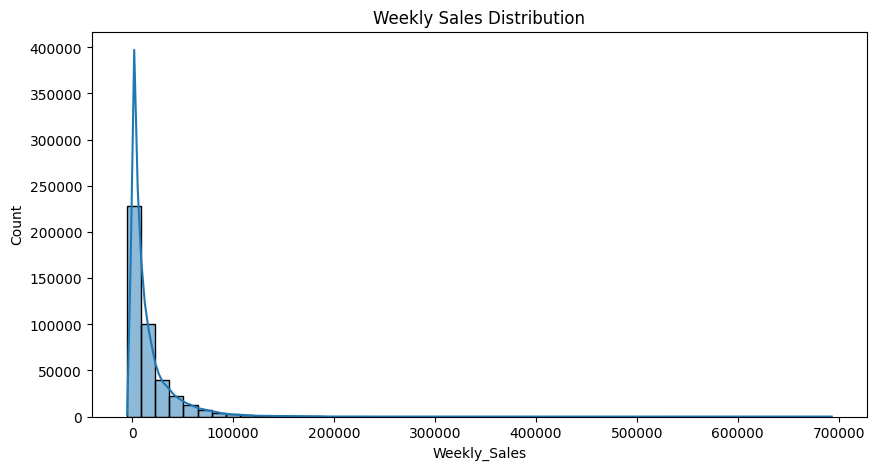

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(merged_df['Weekly_Sales'], bins=50, kde=True)
plt.title('Weekly Sales Distribution')
plt.show()

Histogram is best for understanding the distribution and spread of continuous numerical variables like weekly sales.

It helps identify:

- sales concentration
- skewness
- outliers
- frequency distribution

Insights Found
- Sales distribution is positively skewed
- Some stores generate extremely high sales
- Majority of sales fall within moderate ranges

Business Impact
- Helps identify high-performing stores
- Supports inventory planning
- Identifies sales concentration patterns

## **CHART 2 — SALES TREND OVER TIME**

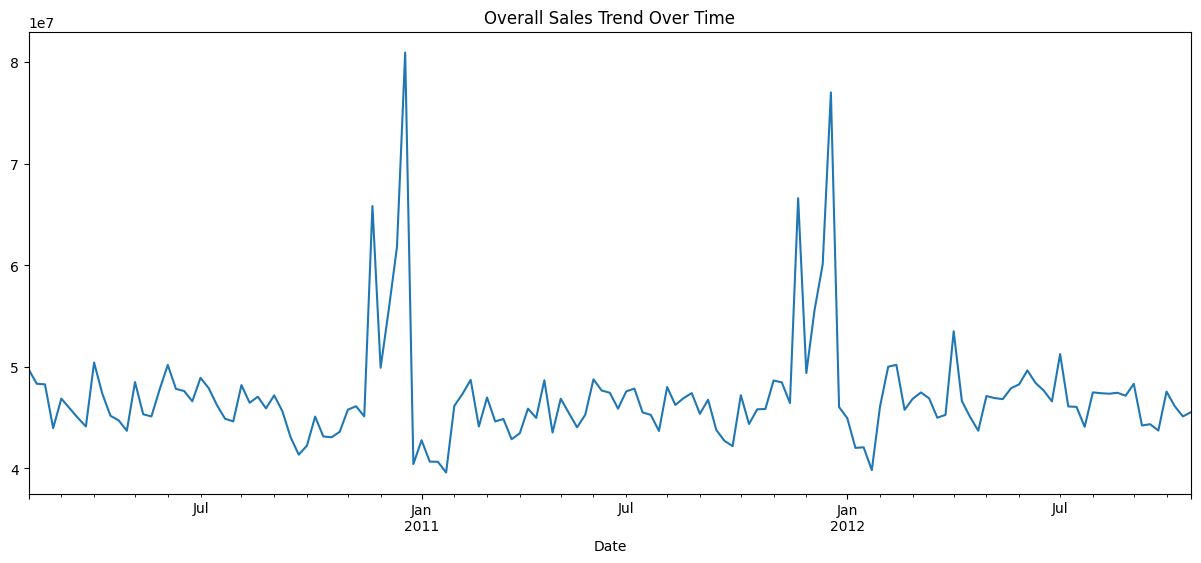

In [25]:
plt.figure(figsize=(15,6))
sales_trend = merged_df.groupby('Date')['Weekly_Sales'].sum()
sales_trend.plot()
plt.title('Overall Sales Trend Over Time')
plt.show()

Why did you pick this chart?
- Line charts are ideal for analyzing trends and patterns over time.

It helps identify:
- seasonal fluctuations
- growth trends
- sales spikes
- long term movement

Insights Found
- Strong seasonal sales patterns exist.
- Holiday periods generate major sales spikes.
- Certain time periods show temporary sales decline.
- Retail demand changes over time.

Business Impact
- Helps forecast future demand more accurately.
- Supports seasonal inventory planning.
- Helps businesses prepare for high-demand periods.
- Improves long-term operational strategy.

## **CHART 3 — STORE TYPE DISTRIBUTION**

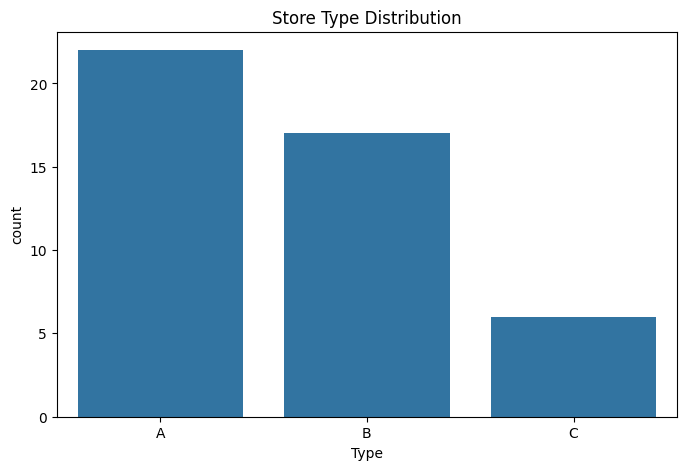

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x='Type', data=stores_data)
plt.title('Store Type Distribution')
plt.show()

Why did you pick this chart?

Countplots are effective for comparing categorical variable distributions like store types.

It helps identify:

- dominant store categories
- operational diversity
- category frequency

Insights Found
- Certain store types dominate the retail network.
- Store distribution is not perfectly balanced.
- Different store categories may contribute differently to sales.

Business Impact
- Helps create store-type-specific strategies.
- Supports targeted operational optimization.
- Enables category-wise performance analysis.
- Improves retail resource allocation.

## **CHART 4 — STORE SIZE DISTRIBUTION**

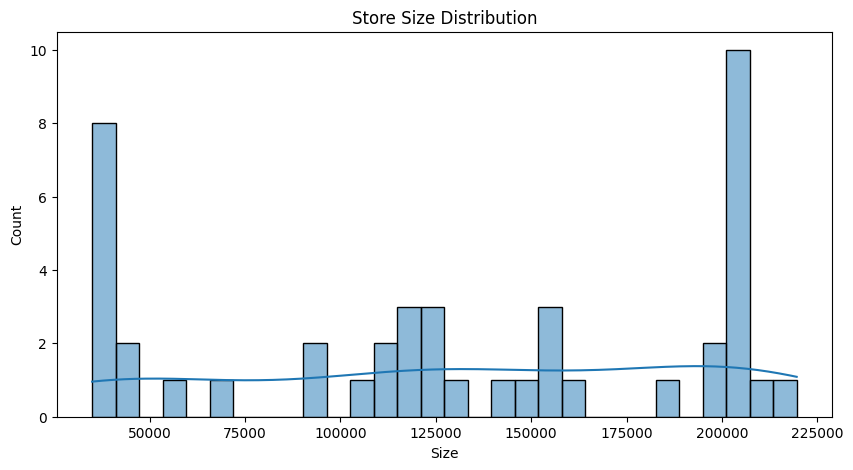

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(stores_data['Size'], bins=30, kde=True)
plt.title('Store Size Distribution')
plt.show()

Why did you pick this chart?

Histogram helps analyze numerical variable distributions such as store size.

It helps identify:

- store capacity spread
- concentration patterns
- operational scale differences

Insights Found
- Store sizes vary significantly across locations.
- Some stores are very large while others are relatively small.
- Store size may strongly influence sales volume.

Business Impact
- Helps optimize inventory allocation.
- Supports store-specific forecasting.
- Larger stores may require higher inventory planning.
- Helps improve operational scalability.

## **CHART 5 — HOLIDAY VS NON-HOLIDAY SALES**

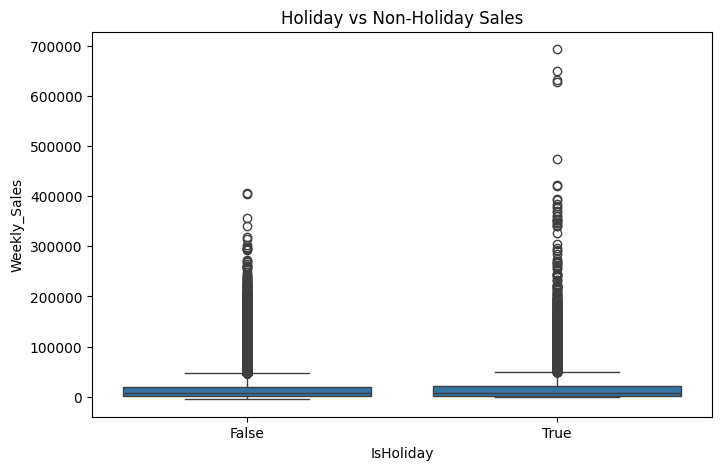

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=merged_df)
plt.title('Holiday vs Non-Holiday Sales')
plt.show()

Why did you pick this chart?

Boxplots are useful for comparing distributions between categories.

It helps identify:

- variability
- median differences
- sales spread
- outliers

Insights Found
- Holiday sales show higher variability.
- Some departments experience significant sales boosts during holidays.
- Holiday periods create extreme sales spikes.

Business Impact
- Helps improve holiday inventory management.
- Supports promotional campaign planning.
- Businesses can optimize staffing during high-demand periods.
- Improves seasonal forecasting accuracy.

## **CHART 6 — CORRELATION HEATMAP**

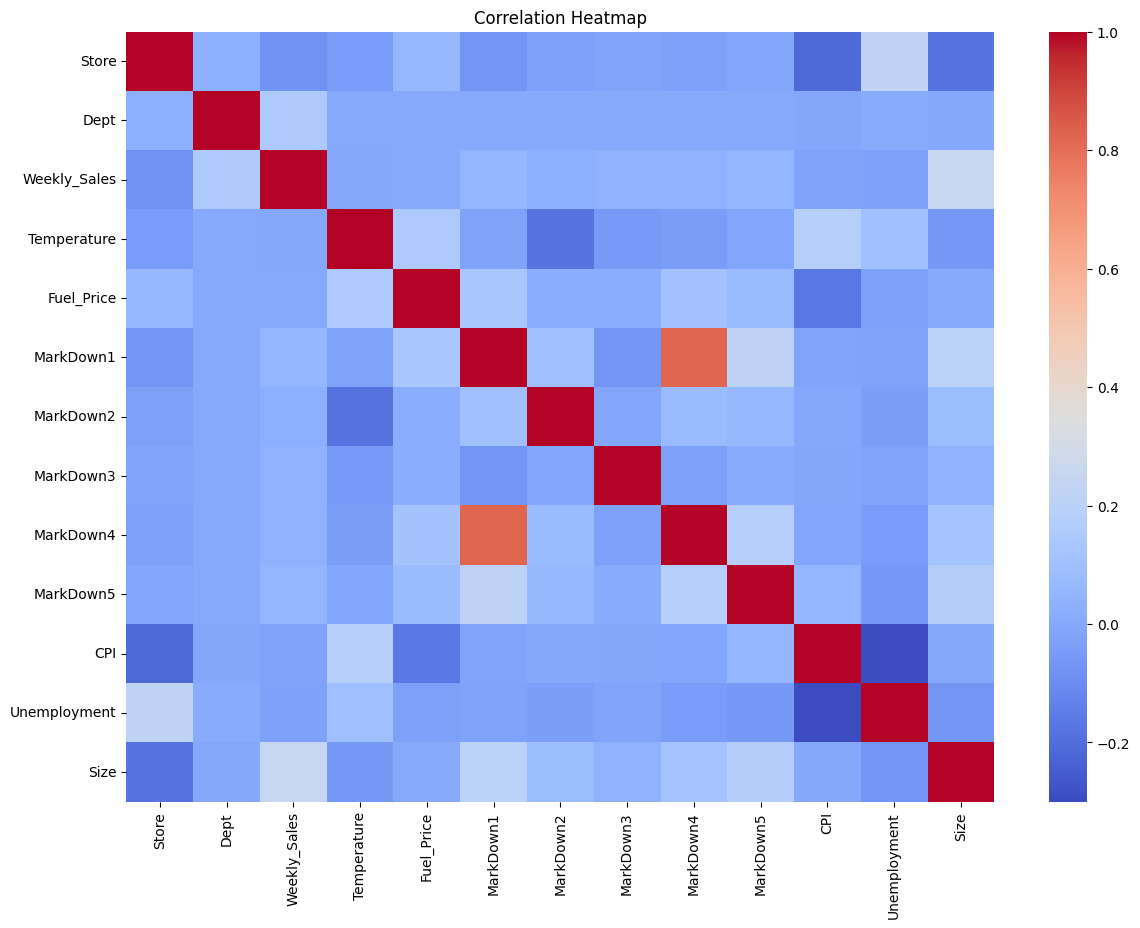

In [29]:
plt.figure(figsize=(14,10))
numeric_cols = merged_df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_cols.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Why did you pick this chart?

Heatmaps help identify relationships among multiple numerical variables simultaneously.

It helps detect:

- positive correlations
- negative correlations
- feature relationships
- multicollinearity

Insights Found
- Some external factors moderately influence weekly sales.
- Markdown variables impact demand patterns.
- Economic indicators show measurable relationships with sales.
- Certain variables are weakly correlated.

Business Impact
- Helps select important forecasting features.
- Improves machine learning model performance.
- Reduces redundant variables.
- Supports better business decision-making.

## **CHART 7 — TOP STORES BY SALES**

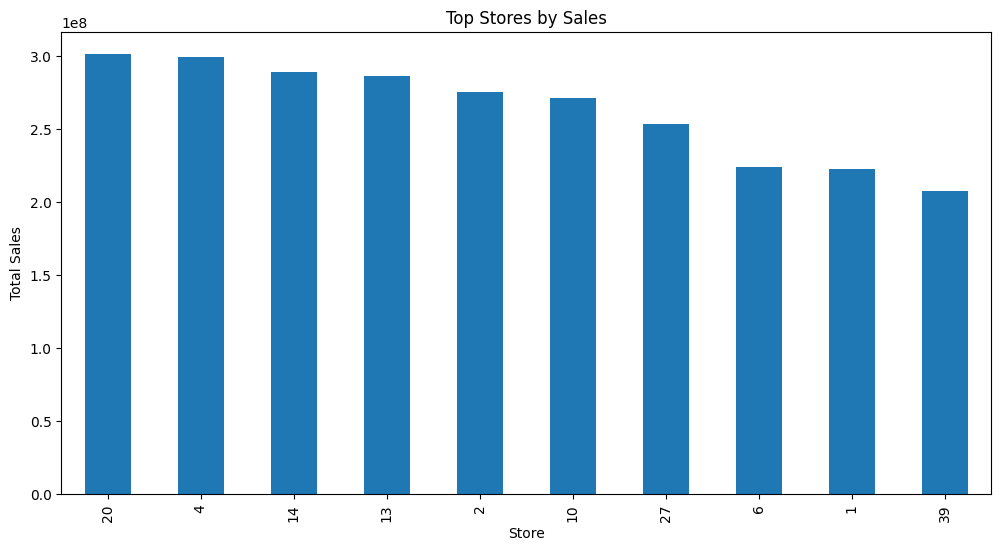

In [30]:
top_stores = merged_df.groupby('Store')['Weekly_Sales'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10)

plt.figure(figsize=(12,6))

top_stores.plot(kind='bar')

plt.title('Top Stores by Sales')

plt.xlabel('Store')
plt.ylabel('Total Sales')

plt.show()

Why did you pick this chart?

Bar charts are ideal for comparing performance across categories like stores.

It helps identify:

- top-performing stores
- sales concentration
- comparative performance

Insights Found
- Certain stores contribute significantly higher revenue.
- Sales performance varies across stores.
- High-performing stores dominate total sales.

Business Impact
- Helps identify benchmark stores.
- Supports high-performing store expansion strategies.
- Enables low-performing store improvement planning.
- Helps optimize regional investments.

## **CHART 8 — MONTHLY SALES ANALYSIS**

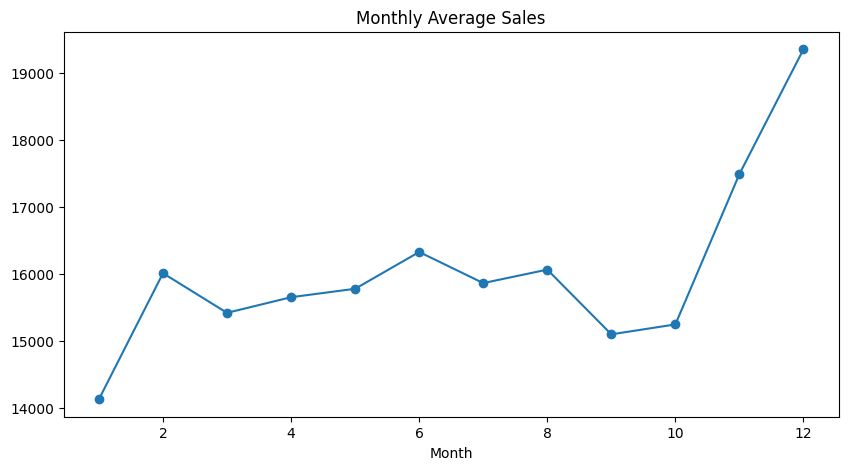

In [31]:
monthly_sales = merged_df.groupby('Month') ['Weekly_Sales'].mean()
plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Average Sales')
plt.show()

Why did you pick this chart?

Line charts effectively show monthly trends and seasonal fluctuations.

It helps identify:

- seasonal demand
- monthly performance
- recurring trends

Insights Found
- Some months consistently generate higher sales.
- Seasonal peaks exist in retail demand.
- Monthly sales variation is clearly visible.

Business Impact
- Helps prepare for peak-demand months.
- Supports monthly inventory optimization.
- Enables seasonal marketing planning.
- Improves annual forecasting strategy.

## **CHART 9 — CPI VS WEEKLY SALES**

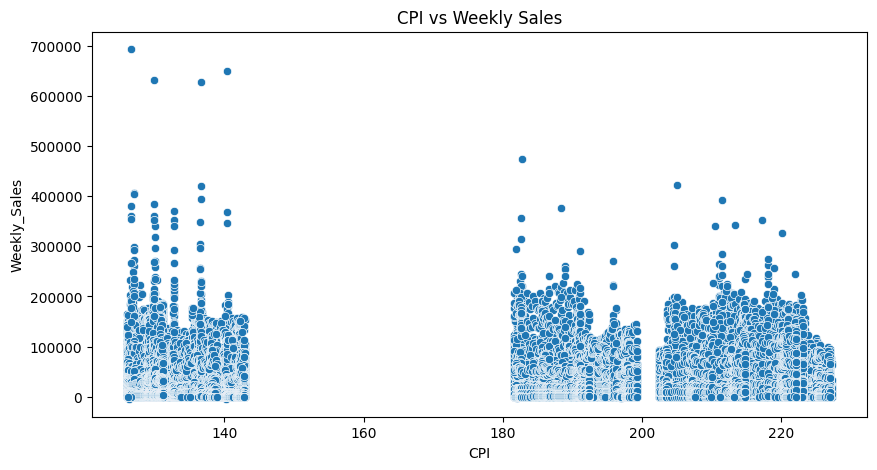

In [32]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='CPI', y='Weekly_Sales', data=merged_df)
plt.title('CPI vs Weekly Sales')
plt.show()

Why did you pick this chart?

Scatterplots are effective for analyzing relationships between two numerical variables.

It helps identify:

- trends
- correlation
- sales sensitivity
- economic influence

Insights Found
- CPI moderately affects retail sales.
- Economic conditions influence customer spending behavior.
- Sales may decline during higher inflation periods.

Business Impact
- Helps businesses monitor economic impacts on demand.
- Supports pricing strategy optimization.
- Enables proactive business planning during inflation periods.
- Improves forecasting accuracy using economic indicators.

## **CHART 10 — UNEMPLOYMENT VS WEEKLY SALES**

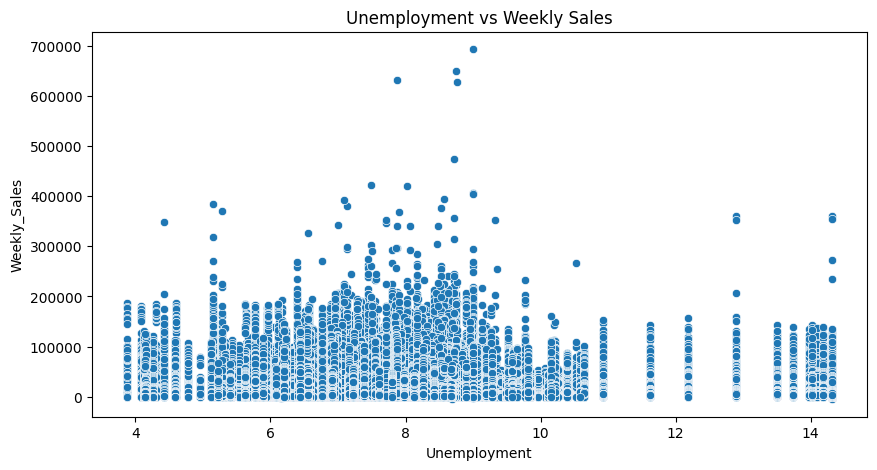

In [33]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=merged_df)
plt.title('Unemployment vs Weekly Sales')
plt.show()

Why did you pick this chart?

Scatterplots help analyze how external economic factors influence sales performance.

It helps identify:

- relationship patterns
- economic sensitivity
- purchasing behavior impact

Insights Found
- Higher unemployment may reduce customer spending power.
- Sales performance can fluctuate with employment conditions.
- Economic instability impacts retail demand.

Business Impact
- Helps businesses adjust pricing strategies.
- Supports risk-aware inventory planning.
- Enables economic-condition-based forecasting.
- Helps businesses prepare for market slowdowns.

# **12. ANOMALY DETECTION**

### Business Objective
### - The objective is to detect unusual sales patterns across stores and departments.

**Using Isolation Forest**

In [34]:
anomaly_data = merged_df[['Weekly_Sales']]
iso_model = IsolationForest(contamination=0.01, random_state=42)
merged_df['Anomaly'] = iso_model.fit_predict(anomaly_data)

**Visualize Anomalies**

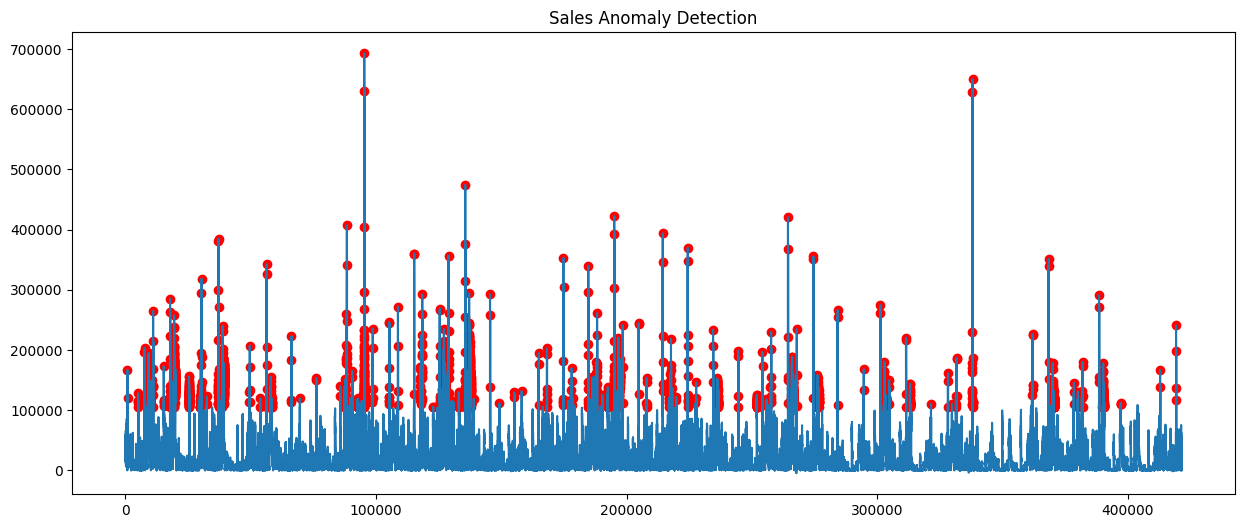

In [35]:
plt.figure(figsize=(15,6))

plt.plot(merged_df['Weekly_Sales'].values)

anomalies = merged_df[merged_df['Anomaly'] ==-1]
plt.scatter(anomalies.index,
anomalies['Weekly_Sales'],
color='red')

plt.title('Sales Anomaly Detection')
plt.show()

Insights Found
- Certain stores show unusually high spikes
- Holiday weeks contribute to anomalies
- Some anomalies may indicate operational issues

Business Impact
- Prevents inventory mismatch
- Helps fraud or error detection
- Improves forecasting quality

# **13. TIME SERIES ANALYSIS**

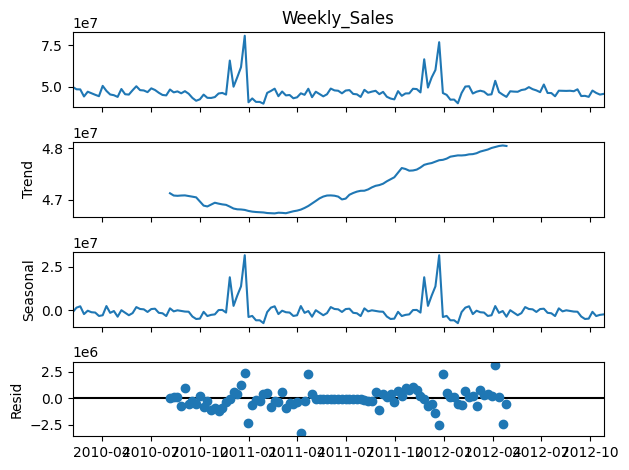

In [36]:
sales_ts = merged_df.groupby('Date')['Weekly_Sales'].sum()

result = seasonal_decompose(sales_ts, model='additive', period=52)

result.plot()
plt.show()

Insights Found
- Strong seasonality exists
- Trend movement visible across years
- Residual components highlight irregular patterns

# **14. FEATURE ENGINEERING**

**Creating Additional Features**

In [37]:
merged_df['Sales_Per_Size'] = merged_df['Weekly_Sales'] / merged_df['Size']

merged_df['Fuel_CPI_Ratio'] = merged_df['Fuel_Price'] / merged_df['CPI']

merged_df['Markdown_Total'] = (
merged_df['MarkDown1'] +
merged_df['MarkDown2'] +
merged_df['MarkDown3'] +
merged_df['MarkDown4'] +
merged_df['MarkDown5']
)

**Encode Categorical Variables**

In [38]:
le = LabelEncoder()

merged_df['Type'] = le.fit_transform(merged_df['Type'])

## **15. CUSTOMER / STORE SEGMENTATION**

**Prepare Segmentation Dataset**

In [39]:
segment_df = merged_df.groupby('Store').agg({
'Weekly_Sales':'mean',
'Markdown_Total':'mean',
'Fuel_Price':'mean',
'CPI':'mean',
'Unemployment':'mean'
}).reset_index()

**Feature Scaling**

In [40]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(segment_df.drop('Store', axis=1))

**Elbow Method**

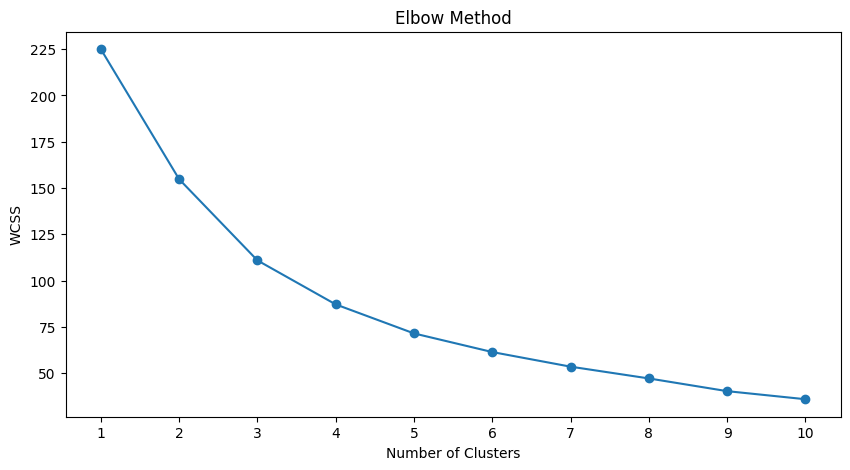

In [41]:
# ==========================================
# Elbow Method for Optimal Clusters
# ==========================================

from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(10,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title('Elbow Method')

plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.xticks(range(1,11))

plt.show()

**Apply KMeans Clustering**

In [42]:
kmeans = KMeans(n_clusters=4, random_state=42)

segment_df['Cluster'] = kmeans.fit_predict(scaled_data)

**Segmentation Quality Evaluation**

In [43]:
score = silhouette_score(scaled_data,
segment_df['Cluster'])
print('Silhouette Score : ', score)

Silhouette Score :  0.3178965619832291


Insights Found
- Stores can be grouped into operational categories
- Some stores respond strongly to markdowns
- Certain clusters generate consistently high sales

Business Impact
- Enables personalized marketing
- Supports region-specific inventory planning
- Improves operational optimization

# **16. Department Co-Occurrence Analysis**

In [44]:
# ==========================================
# Department Co-Occurrence Matrix
# ==========================================

dept_pivot = pd.pivot_table(
    merged_df,
    values='Weekly_Sales',
    index='Date',
    columns='Dept',
    aggfunc='sum',
    fill_value=0
)

print('Department Pivot Table Created')

dept_pivot.head()

Department Pivot Table Created


Dept,1,2,3,4,5,6,7,8,9,10,...,90,91,92,93,94,95,96,97,98,99
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-05,881833.41,1997831.89,484368.90,1205801.77,1116952.54,206793.28,764967.96,1527438.17,535727.56,773682.90,...,2199107.52,1755822.24,3781162.87,1165221.80,1301383.11,3170529.93,404386.06,656075.00,293125.35,0.03
2010-02-12,1457182.40,1839217.77,429341.02,1075081.62,1148132.32,252086.57,781977.02,1375373.29,562174.72,762338.46,...,2031157.15,1603013.19,3443837.30,1077422.70,1317069.86,2976149.31,448865.03,613648.81,377482.79,0.01
2010-02-19,1118257.36,1961685.93,410399.14,1113781.74,1110717.47,258741.79,843175.36,1414318.21,587592.22,780288.54,...,1976215.64,1546117.67,3312991.71,1005051.42,1513229.84,2814037.79,395923.92,569748.82,304997.85,8.99
2010-02-26,681391.58,1859531.58,415060.22,1075834.39,855568.94,212400.43,719317.34,1367537.17,561960.46,776371.88,...,1935114.73,1486244.19,3204210.06,950067.10,1212218.70,2789412.13,399232.45,546678.24,265868.75,0.00
2010-03-05,762652.57,1957870.82,422680.37,1145506.25,930687.44,203133.97,779520.28,1454252.09,630097.86,762684.04,...,2005670.83,1607815.57,3480725.21,1052044.39,1287397.56,2994339.24,394973.61,598588.05,270907.25,0.03


In [45]:
# ==========================================
# Department Correlation Matrix
# ==========================================

dept_corr = dept_pivot.corr()

print('Correlation Matrix Created')

dept_corr.head()

Correlation Matrix Created


Dept,1,2,3,4,5,6,7,8,9,10,...,90,91,92,93,94,95,96,97,98,99
Dept,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.261559,-0.173061,0.017302,0.513601,0.295781,0.489972,0.513402,-0.071520,0.193405,...,0.404231,0.032967,0.334751,0.138123,-0.050898,-0.233085,-0.044193,-0.098588,0.647681,0.265686
2,0.261559,1.000000,0.424812,0.721706,0.345572,0.410774,0.591915,0.671484,0.545213,0.695223,...,0.503639,0.249068,0.419944,0.472058,0.325083,0.566541,0.463504,0.525091,0.361581,0.387066
3,-0.173061,0.424812,1.000000,0.457733,-0.111690,-0.031609,-0.048925,-0.067416,0.180921,0.163630,...,0.062142,-0.008273,0.015343,0.013431,0.048452,0.285822,0.158761,0.244190,-0.196648,0.023986
4,0.017302,0.721706,0.457733,1.000000,0.275560,0.359254,0.434208,0.475531,0.542812,0.667213,...,0.566248,0.276722,0.537261,0.694791,0.238307,0.571865,0.676755,0.648105,0.259998,0.316424
5,0.513601,0.345572,-0.111690,0.275560,1.000000,0.860030,0.872463,0.554877,-0.023420,0.294491,...,0.536080,-0.068984,0.520841,0.258594,-0.205724,-0.283629,0.134780,-0.189490,0.820060,0.505759


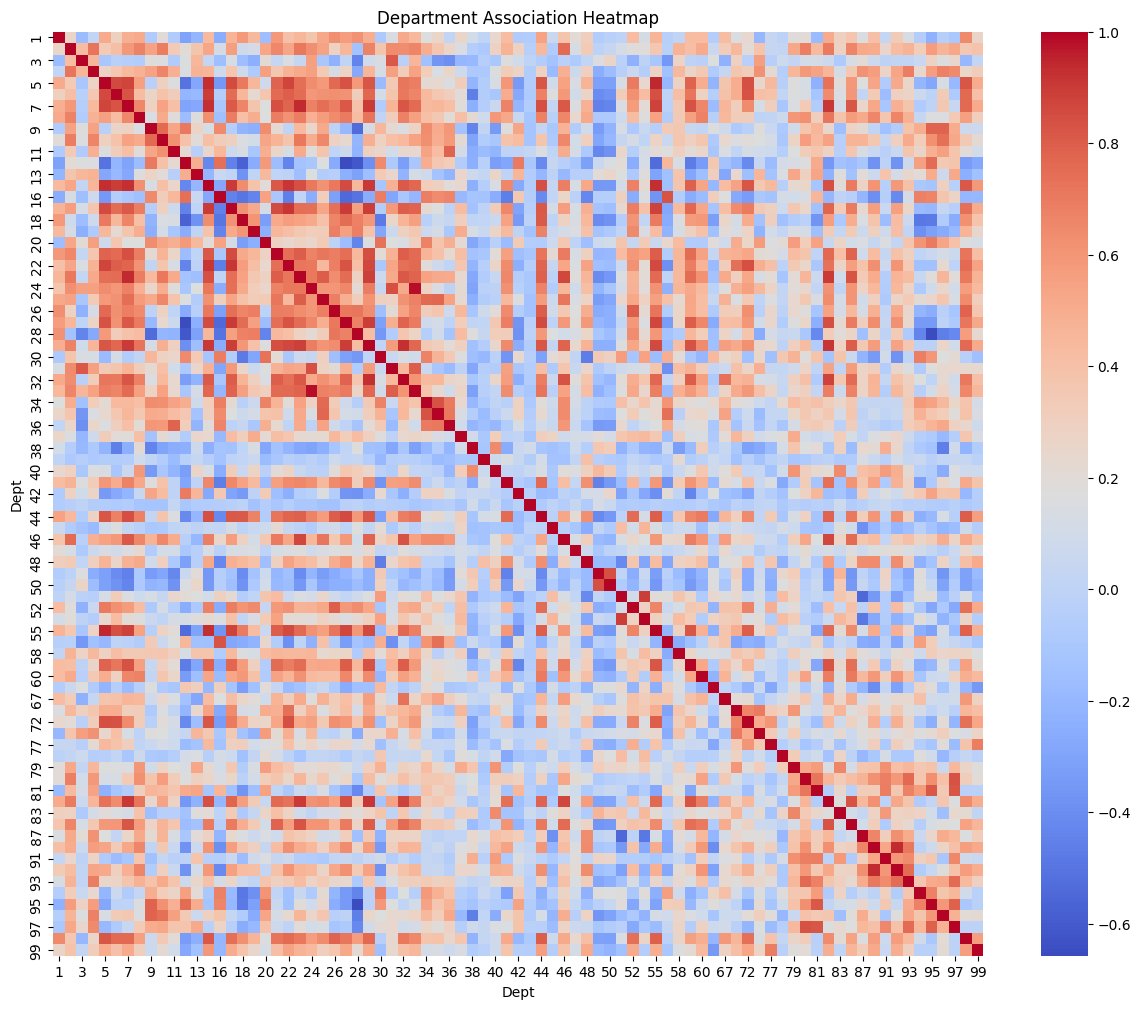

In [46]:
# ==========================================
# Department Association Heatmap
# ==========================================

plt.figure(figsize=(15,12))

sns.heatmap(
    dept_corr,
    cmap='coolwarm'
)

plt.title('Department Association Heatmap')

plt.show()

In [47]:
# ==========================================
# Strong Department Associations
# ==========================================

corr_pairs = (
    dept_corr.unstack()
    .sort_values(kind='quicksort', ascending=False)
)

corr_pairs = corr_pairs[
    (corr_pairs < 1.0) &
    (corr_pairs > 0.7)
]

corr_pairs.head(20)

,,0
Dept,Dept,
24,33,0.981377
33,24,0.981377
55,5,0.942768
5,55,0.942768
90,92,0.938477
92,90,0.938477
7,23,0.936404
23,7,0.936404
55,14,0.934023


**Why did you pick this approach?**

Correlation-based department association analysis helps identify departments with similar sales movement patterns.

It helps infer:

- co-purchasing behavior
- promotional relationships
- cross-selling opportunities

without requiring transaction-level customer data.

Insights Found
- Certain departments show strong positive sales relationships.
- Some product categories experience demand together.
- Seasonal and promotional patterns influence department associations.
- High-correlation departments may support bundled marketing.

Business Impact
- Supports cross-selling strategies.
- Helps optimize promotional campaigns.
- Improves product placement planning.
- Enhances bundled marketing opportunities.
- Helps inventory coordination across related departments.

# **17. DEMAND FORECASTING**

**Prepare Forecasting Dataset**

In [48]:
forecast_df = merged_df.copy()

**Select Features**

In [49]:
features = [
'Store',
'Dept',
'Temperature',
'Fuel_Price',
'CPI',
'Unemployment',
'IsHoliday',
'Type',
'Size',
'Markdown_Total'
]
X = forecast_df[features]
y = forecast_df['Weekly_Sales']

**Train Test Split**

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42
)

# **MODEL 1 — LINEAR REGRESSION**

In [51]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# **MODEL 2 — RANDOM FOREST REGRESSOR**

In [52]:
rf_model = RandomForestRegressor(
n_estimators=100,
random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# **MODEL 3 — XGBOOST REGRESSOR**

In [53]:
xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

# **18. MODEL EVALUATION**

**Evaluation Function**

In [56]:
import math

def evaluate_model(y_true, y_pred, model_name):

  mae = mean_absolute_error(y_true, y_pred)
  rmse = math.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)

  return {
    'Model': model_name,
    'MAE': mae,
    'RMSE': rmse,
    'R2 Score': r2
}

**Model Comparison**

In [57]:
results = []

results.append(evaluate_model(y_test, lr_pred, 'Linear Regression'))
results.append(evaluate_model(y_test, rf_pred, 'Random Forest'))
results.append(evaluate_model(y_test, xgb_pred, 'XGBoost'))

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,14556.684940,21803.875534,0.088331
1,Random Forest,1934.302395,5576.043829,0.940376
2,XGBoost,3288.810201,6763.774004,0.912270


**Best Model Selection**

In [58]:
results_df.sort_values(by='R2 Score', ascending=False)

,Model,MAE,RMSE,R2 Score
1,Random Forest,1934.302395,5576.043829,0.940376
2,XGBoost,3288.810201,6763.774004,0.912270
0,Linear Regression,14556.684940,21803.875534,0.088331


## **Why Random Forest / XGBoost Performs Better?**

Reasons:
1. Handles nonlinear relationships effectively
2. Captures complex sales patterns
3. Works well with large retail datasets
4. Handles feature interactions efficiently

# **19. PROPHET FORECASTING MODEL**

**Prepare Data for Prophet**

In [59]:
prophet_df = merged_df.groupby('Date')['Weekly_Sales'].sum().reset_index()

prophet_df.columns = ['ds','y']

**Train Prophet Model**

In [60]:
prophet_model = Prophet()

prophet_model.fit(prophet_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


**Future Forecast**

In [61]:
future = prophet_model.make_future_dataframe(periods=52, freq='W')

forecast = prophet_model.predict(future)

**Forecast Visualization**

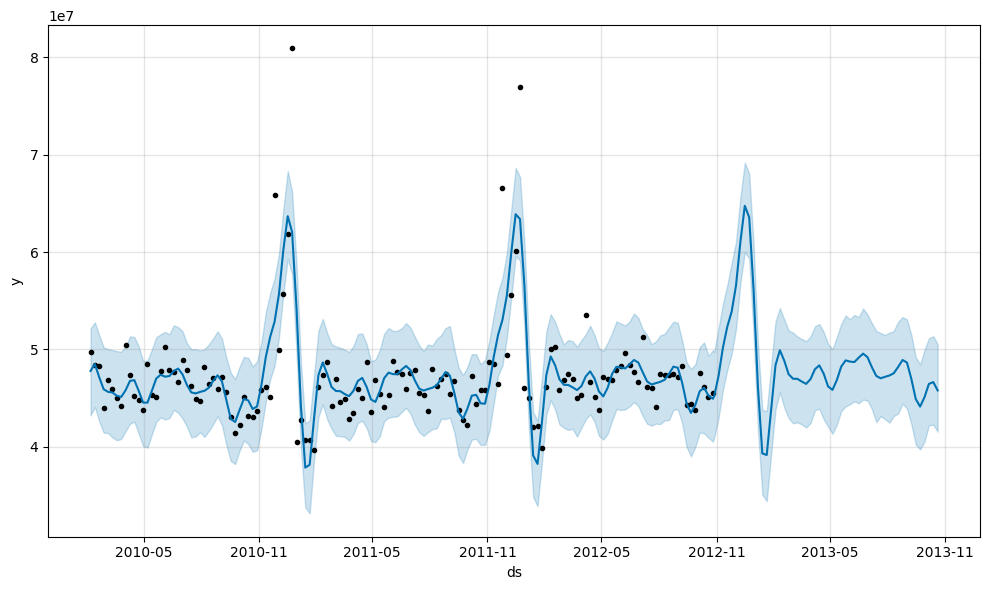

In [62]:
prophet_model.plot(forecast)
plt.show()

# **20. IMPACT OF EXTERNAL FACTORS**

**CPI Impact**

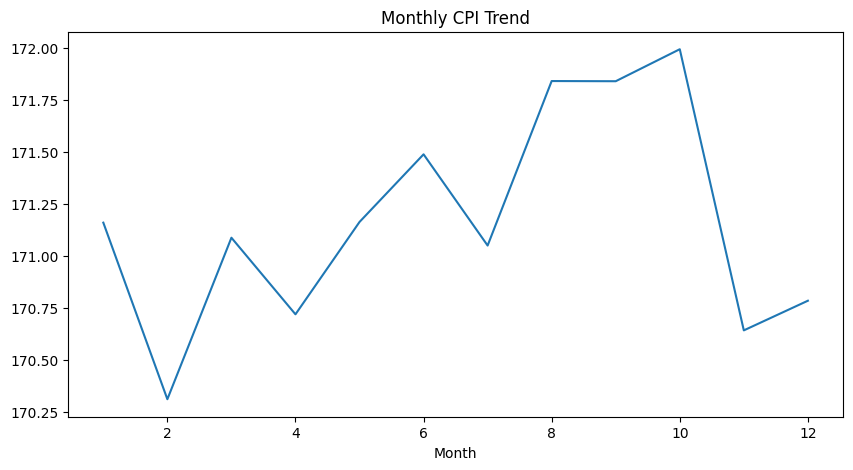

In [63]:
merged_df.groupby('Month')['CPI'].mean().plot(figsize=(10,5))

plt.title('Monthly CPI Trend')
plt.show()

**Fuel Price Impact**

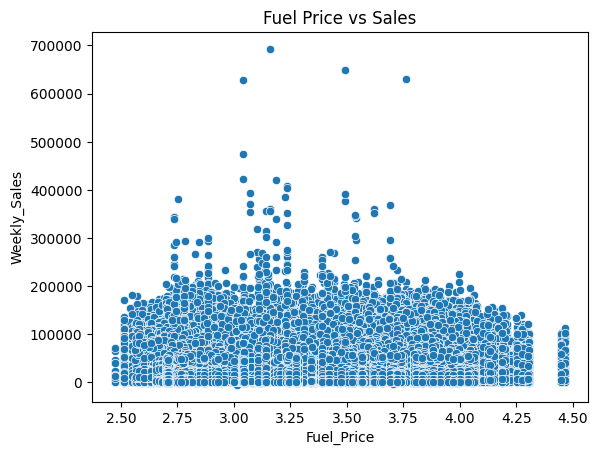

In [64]:
sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=merged_df)

plt.title('Fuel Price vs Sales')
plt.show()

**Unemployment Impact**

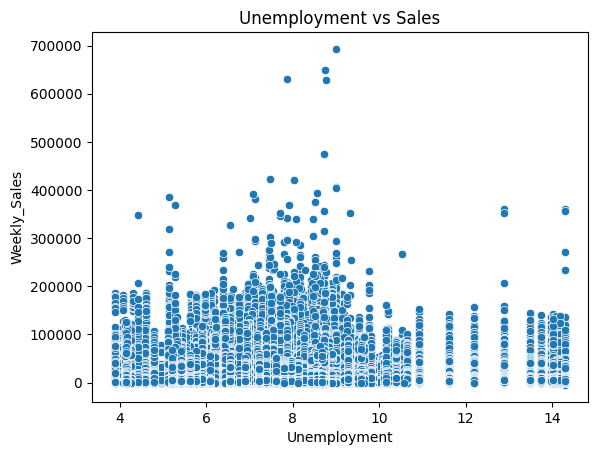

In [65]:
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=merged_df)

plt.title('Unemployment vs Sales')
plt.show()

INSIGHTS FROM EXTERNAL FACTORS
1. Economic indicators influence customer purchasing behavior
2. Fuel prices impact customer mobility and spending
3. CPI fluctuations may affect demand patterns
4. Unemployment can reduce purchasing power

# **21. PERSONALIZED MARKETING STRATEGIES**

**Suggested Strategies**

High Performing Stores
- Premium product placement
- Loyalty programs
- Personalized recommendations

Medium Performing Stores
- Seasonal discount campaigns
- Regional marketing optimization
- Cross-selling strategies

Low Performing Stores
- Localized promotions
- Inventory restructuring
- Demand stimulation campaigns

# **22. INVENTORY MANAGEMENT STRATEGIES**

**Strategy Recommendations**
- Maintain higher inventory during seasonal peaks
- Use forecasting outputs for stock planning
- Reduce overstocking in low-demand departments
- Create regional inventory strategies
- Improve holiday demand planning

# **23. REAL-WORLD IMPLEMENTATION CHALLENGES**

Potential Challenges
- Dynamic consumer behavior
- External economic instability
- Data quality issues
- Real-time inventory synchronization
- Seasonal unpredictability
- Supply chain disruptions
- Regional purchasing variability

# **24. OVERALL BUSINESS IMPACT**

Expected Outcomes
- Improved forecasting accuracy
- Better inventory optimization
- Reduced operational losses
- Enhanced customer targeting
- Improved promotional effectiveness
- Data-driven decision making
- Increased revenue opportunities

# **25. CONCLUSION**

This project successfully developed an end-to-end Advanced Retail Analytics System capable of:
- Detecting anomalies in sales data
- Forecasting future retail demand
- Segmenting stores based on operational patterns
- Understanding external economic influences
- Developing strategic marketing recommendations


The integration of:
- machine learning
- clustering
- time-series forecasting
- anomaly detection
- retail analytics

helps create a scalable and intelligent retail optimization framework.


The project demonstrates how advanced analytics can support real-world business decision-making in
modern retail ecosystems.

# **26. FUTURE SCOPE**

Future Enhancements
1. Real-time forecasting dashboards
2. Deep learning forecasting models (LSTM)
3. Automated inventory optimization
4. AI-driven recommendation systems
5. Real-time anomaly alerts
6. Regional climate integration
7. Cloud deployment and MLOps pipelines
8. Interactive BI dashboards



---



# **THANK YOU**

**Rihansh**